In [19]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

import cornac
from cornac.models import SVD, WMF, PMF,CTR, CDL, BPR,EASE
from cornac.eval_methods import RatioSplit
from cornac.metrics import NDCG, Precision, Recall


In [20]:
# products_df = pd.read_csv('data/clean_products.csv')
reviews_df = pd.read_csv(r'C:\Users\dcheruiyot2\OneDrive - KPMG\Projects\rec-sys\dataset\utility\reviews.csv')

reviews_df.head()

,Unnamed: 0,folder_name,ASIN,ProductName,price,image,reviewerID,customerReview,reviewDate,reviewLocation,reviewVotes,category
0,0,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,ChrisChris_AERHRY53MCLOIYM2EUPROS7VFBBA,5.0,"September 15, 2020",United States,183,Kitchen
1,1,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Abby J. _AHYVM23MR42XCBX3U3VPAOJKSYPA,5.0,"December 5, 2020",United States,515,Kitchen
2,2,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Westman_d5857da1-8118-4b79-a8ec-f8b2a42f1203,5.0,"January 22, 2024",Canada,0,Kitchen
3,3,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Dr Sandra Curwin_b63caf8e-60d6-4029-b664-f2315...,5.0,"November 17, 2023",Canada,8,Kitchen
4,4,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Marcbp_9cb6a31f-4237-4778-9146-f6faa471e49f,5.0,"September 16, 2023",Mexico,0,Kitchen


In [21]:
def data_struc(df):
    print(f"Columns: {df.columns.tolist()} \n")
    print(f"Unique values: \n{df.nunique()} \n")
    print(df.describe())
    return df.head(3)

def null_profile(df):
    null_pct = (df.isnull().sum()/len(df)*100).round(2)
    return (null_pct.sort_values(ascending=False))

print(f"\nNull columns % : \n {null_profile(reviews_df)}",) 
data_struc(reviews_df)




Null columns % : 
 price             3.42
ProductName       0.04
image             0.04
Unnamed: 0        0.00
ASIN              0.00
folder_name       0.00
reviewerID        0.00
customerReview    0.00
reviewDate        0.00
reviewLocation    0.00
reviewVotes       0.00
category          0.00
dtype: float64
Columns: ['Unnamed: 0', 'folder_name', 'ASIN', 'ProductName', 'price', 'image', 'reviewerID', 'customerReview', 'reviewDate', 'reviewLocation', 'reviewVotes', 'category'] 

Unique values: 
Unnamed: 0        324662
folder_name          167
ASIN               33510
ProductName        33489
price               5581
image              33381
reviewerID        296498
customerReview         5
reviewDate          4351
reviewLocation        17
reviewVotes          482
category              17
dtype: int64 

          Unnamed: 0          price  customerReview    reviewVotes
count  324662.000000  313545.000000   324662.000000  324662.000000
mean   162591.421275      53.158714        4.526424

,Unnamed: 0,folder_name,ASIN,ProductName,price,image,reviewerID,customerReview,reviewDate,reviewLocation,reviewVotes,category
0,0,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,ChrisChris_AERHRY53MCLOIYM2EUPROS7VFBBA,5.0,"September 15, 2020",United States,183,Kitchen
1,1,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Abby J. _AHYVM23MR42XCBX3U3VPAOJKSYPA,5.0,"December 5, 2020",United States,515,Kitchen
2,2,microwave,b085fzxzj5,toshiba_mlem45pitbs_countertop_microwave_oven_...,169.99,https://images-na.ssl-images-amazon.com/images...,Westman_d5857da1-8118-4b79-a8ec-f8b2a42f1203,5.0,"January 22, 2024",Canada,0,Kitchen


In [22]:
reviews_df= reviews_df.drop(['Unnamed: 0'], axis=1)
# to date
reviews_df['reviewDate'] = pd.to_datetime(reviews_df['reviewDate'], errors='coerce')

# null fields
reviews_df['price'] = reviews_df['price'].fillna(0.0)
reviews_df['ProductName'] = reviews_df['ProductName'].fillna('')
reviews_df['image'] = reviews_df['image'].fillna('')
reviews_df.describe()


,price,customerReview,reviewDate,reviewVotes
count,324662.000000,324662.000000,324662,324662.000000
mean,51.338465,4.526424,2023-05-02 08:31:30.625943808,2.780372
min,0.000000,1.000000,1999-05-15 00:00:00,0.000000
25%,11.430000,5.000000,2023-06-17 00:00:00,0.000000
50%,21.990000,5.000000,2023-12-04 00:00:00,0.000000
75%,44.780000,5.000000,2024-01-18 00:00:00,0.000000
max,30099.990000,5.000000,2024-02-17 00:00:00,997.000000
std,224.934299,1.000566,NaN,19.705365


In [23]:
def interaction_density(df, user_col, item_col):
    per_user=df.groupby(user_col)[item_col].count()
    per_item=df.groupby(item_col)[user_col].count()
    print(f"Reviews per user: \n{per_user.describe()}\n")
    print(f"Reviews per product: \n{per_item.describe()}\n")
    print(f"Users with only 1 review: {(per_user == 1).sum():,} ({(per_user == 1).mean()*100:.1f}%)")
    print(f"Users with less than 5 reviews: {(per_user < 5).sum():,} ({(per_user < 5).mean()*100:.1f}%)")
    print(f"Users with more than 5 reviews: {(per_user > 5).sum():,} ({(per_user > 5).mean()*100:.1f}%)")
    print(f"Products with less than 5 reviews: {(per_item < 5).sum():,} ({(per_item < 5).mean()*100:.1f}%)")


def duplicate_reviews(df):
    """clean up reviews df ie.e where the user reviews a product twice"""
    dupl_reviews = df.duplicated(subset=['ASIN','reviewerID'], keep=False).sum()
    # df['reviewerID'] = df['reviewerLink'].str.extract(r'/amzn1.account.([A-Z0-9]+)(?:/ref=|$)')
    # df[df.duplicated(subset=['ASIN','reviewerID'], keep=False)].sort_values(by='reviewerID').groupby(['reviewerID','ASIN']).size()
    df = df.drop_duplicates(subset=['ASIN','reviewerID'], keep='first')

    print("Number of duplicate records: ", dupl_reviews)
    # print(df[df.duplicated(subset=['ASIN','reviewerID'], keep=False)].sort_values(by='reviewerID'))
    print("Number of records after deduplication:",df.shape)

def check_duplicates(df,col):
    dup = df[df.duplicated(subset=col, keep=False)].sort_values(col)
    return dup


check_duplicates(reviews_df, ['ASIN','reviewerID'])
duplicate_reviews(reviews_df)
interaction_density(reviews_df,'reviewerID','ASIN')


Number of duplicate records:  12945
Number of records after deduplication: (318027, 11)
Reviews per user: 
count    296498.000000
mean          1.094989
std           0.438168
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          33.000000
Name: ASIN, dtype: float64

Reviews per product: 
count    33510.000000
mean         9.688511
std          3.787007
min          1.000000
25%          8.000000
50%          9.000000
75%         13.000000
max         52.000000
Name: reviewerID, dtype: float64

Users with only 1 review: 274,915 (92.7%)
Users with less than 5 reviews: 296,039 (99.8%)
Users with more than 5 reviews: 271 (0.1%)
Products with less than 5 reviews: 2,670 (8.0%)


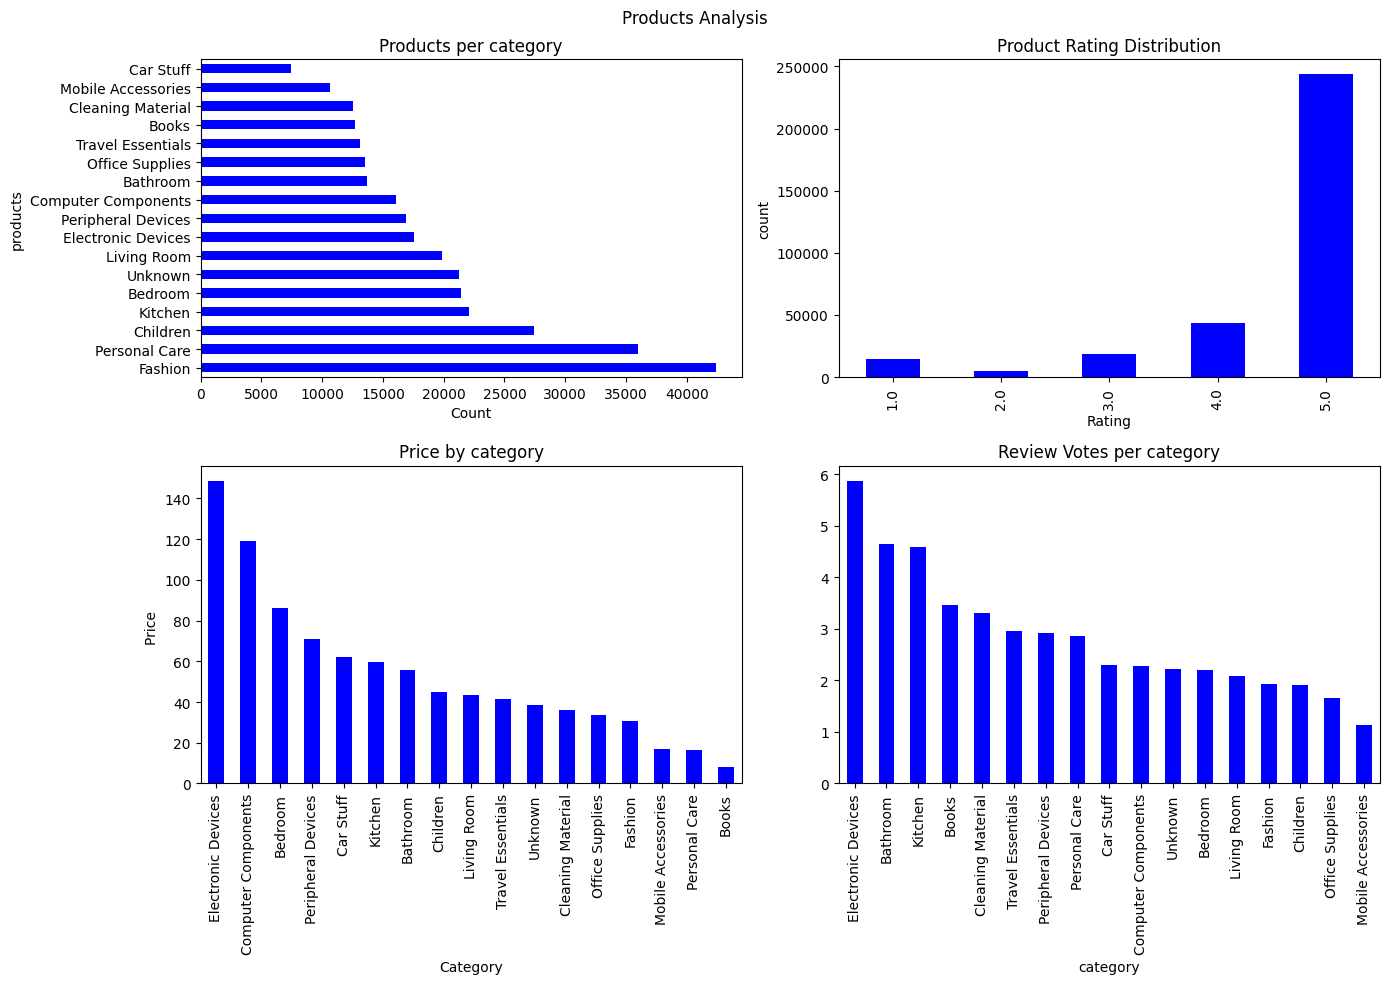

In [24]:
fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle("Products Analysis")

products_per_category = reviews_df['category'].value_counts()
products_per_category.plot(kind='barh', color=['blue'], ax=axes[0,0])
axes[0,0].set_title('Products per category')
axes[0,0].set_xlabel('Count')
axes[0,0].set_ylabel('products')

ratings_dist = reviews_df['customerReview'].value_counts().sort_index()
ratings_dist.plot(kind='bar', color=['blue'], ax=axes[0,1])
axes[0,1].set_title('Product Rating Distribution')
axes[0,1].set_xlabel('Rating')
axes[0,1].set_ylabel('count')

price_by_category = reviews_df.groupby('category')['price'].mean().sort_values(ascending=False)
price_by_category.plot(kind='bar',color='blue', ax=axes[1,0])
axes[1,0].set_title('Price by category')
axes[1,0].set_xlabel('Category')
axes[1,0].set_ylabel('Price ')

reviewVotes = reviews_df.groupby('category')['reviewVotes'].mean().sort_values(ascending=False)
reviewVotes.plot(kind='bar',color=['blue'], ax=axes[1,1])
axes[1,1].set_title("Review Votes per category")
axes[1,1].set_xticklabels
   
plt.tight_layout()
plt.show()

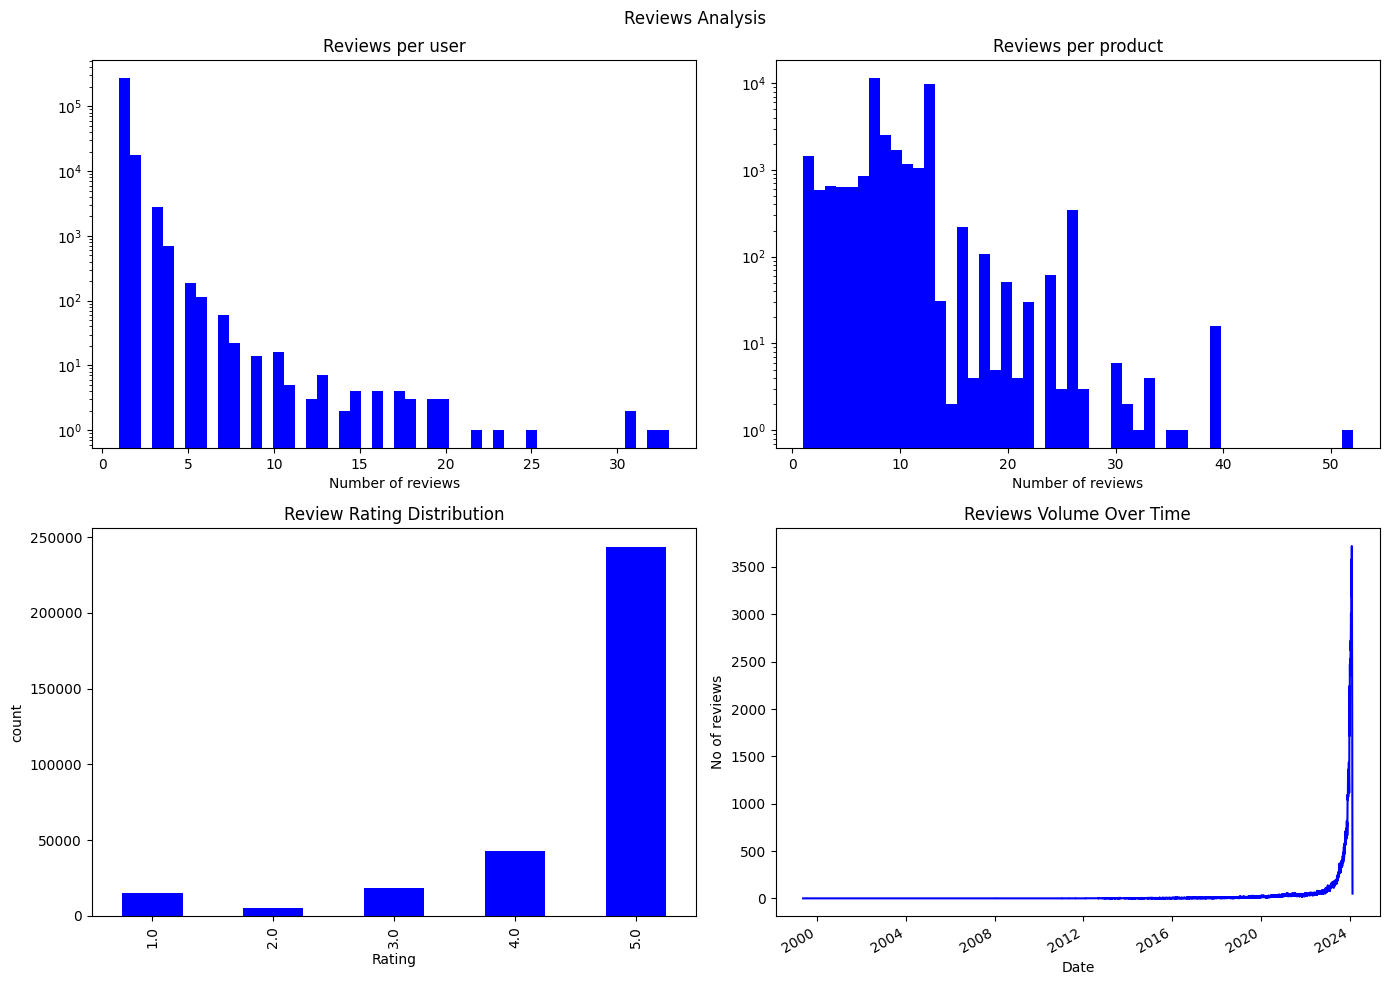

% ratings 4 and above: 88.29859977453475


In [25]:
user_counts=reviews_df.groupby('reviewerID')['customerReview'].count()
product_counts=reviews_df.groupby('ASIN')['customerReview'].count()


fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle("Reviews Analysis")

axes[0,0].hist(user_counts, color='blue', bins=50, log=True)
axes[0,0].set_title('Reviews per user')
axes[0,0].set_xlabel('Number of reviews')

axes[0,1].hist(product_counts, color='blue', bins=50, log=True)
axes[0,1].set_title('Reviews per product')
axes[0,1].set_xlabel('Number of reviews')

ratings_dist = reviews_df['customerReview'].value_counts().sort_index()
ratings_dist.plot(kind='bar', color=['blue'], ax=axes[1,0])
axes[1,0].set_title('Review Rating Distribution')
axes[1,0].set_xlabel('Rating')
axes[1,0].set_ylabel('count')


reviews_overtime =reviews_df.groupby('reviewDate').size()
reviews_overtime.plot(kind='line', color='blue', ax=axes[1,1])
axes[1,1].set_title('Reviews Volume Over Time')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('No of reviews')


   
plt.tight_layout()
plt.show()

print(f"% ratings 4 and above: {(reviews_df['customerReview']>=4).mean()*100}")

In [88]:
products_df = df.drop_duplicates(subset='ASIN', keep='first')
products_df=products_df[['ASIN', 'ProductName','image','category']].reset_index(drop=True)
products_df.head()

,ASIN,ProductName,image,category
0,b000iw9j20,cuisinart_cmw100_1cubicfoot_stainless_steel_mi...,https://images-na.ssl-images-amazon.com/images...,Kitchen
1,b086jp7fx9,the_original_korcci_microwaveable_silicone_pop...,https://images-na.ssl-images-amazon.com/images...,Kitchen
2,b07jfl43nx,the_original_popco_silicone_microwave_popcorn_...,https://images-na.ssl-images-amazon.com/images...,Kitchen
3,b08k8t3w2v,cosori_smart_12in1_air_fryer_toaster_oven_comb...,https://images-na.ssl-images-amazon.com/images...,Kitchen
4,b07scgy2h6,ninja_sp101_digital_air_fry_countertop_oven_wi...,https://images-na.ssl-images-amazon.com/images...,Kitchen


In [26]:
df= reviews_df.copy()

In [27]:
df['id'] = df['reviewerID'].astype(str).str[-28:]
review_counts = df.groupby('reviewerID').size()
len(review_counts)
active_users=review_counts[review_counts >= 3].index
df = df[df['reviewerID'].isin(active_users)].copy()

df['customerReview'] = df['customerReview'].astype(float)
active_users

Index(['#AskMissPatience_AGTMGTCCD2F45YP7J7TWBUEDFQYA',
       '#EmptyNestReader_AHOZE5RMLR5EXZT7CTVYXK7MJUAA',
       '***Toy Collector******Toy Collector***_AG5NFKDKQNEYV76GKH7BMXNTHKSQ',
       '***Toy Collector***_AG5NFKDKQNEYV76GKH7BMXNTHKSQ',
       '*CoNvInCeD*_AHD4WQDB7UNX2AXX5JLNC36XZ7MA',
       ',......._AGZDNPPKKVVZRO2WDT3BSRMMRHMA',
       '1feedback_AHTCLWZ4464VDP3IN6JKRPABSEUQ',
       '21Handicrafts_AE754MFKHICK6LJSBBE6AFBIGSRQ',
       '2redhot_AGCXRODHXOWWF6X3YD3W6OVV6DJQ',
       '3R2_AH4VON57QSGL5MJPII6NOBVRLQEA',
       ...
       'zach thomas_AEEMEXXFFR2I4YNKVAYWFOOD2D7Q',
       'zhao11_AFQ426RQSRSZBS6VKRI4OUR2NTUQ',
       '~KiteFlier_AH6CVV3VOK6LEKNUJUQ6QCPPJVDA',
       '¤♤♡◇♧□○°_AGUTZC4GHLTGYHA3KBEDRF6MHB6A',
       '🌺 Lynne E._AEYGPUCRKH7G4VM22FM3VAKSQ23Q',
       '🌿 𝔽𝕖𝕣𝕟 🌿_AGQNQ6OJOXQCPOTFSRTWAXYXNHLA',
       '👱🏻‍♀️Amy_AF4Y5UC5FYGVBSO746YJYJLQTQSA',
       '💜I Love Jellybeans_AHXMSF4ZL5IUD4QPIWCRQVMFJVGQ',
       '🔅_AGY3WMETXVMOG7FXK6DZ4RL2SJOA',
       '🤗

In [28]:
def build_dataset(df):
    df['feedback'] = (df['customerReview'] >= 4).astype(float)
    triplets = list(zip(
        df['reviewerID'].tolist(),
        df['ASIN'].tolist(),
        df['feedback'].tolist()
    ))

    return triplets

triplets =build_dataset(df)
triplets

[('benjamin bannister_AFNRBTSF72OCUH3QDSVF5AJQIXFA', 'b000iw9j20', 1.0),
 ('W Hart_AHGYVAMJW4OHDZ2MIFLURL4TWEGQ', 'b086jp7fx9', 1.0),
 ('Rotsterne_AG7S5ICN4F2K3346LLB7CRWUUVCQ', 'b086jp7fx9', 1.0),
 ('shopathomeguy_AGVGIJBDPEGHCXZ47J46JLX3E4VA', 'b07jfl43nx', 1.0),
 ('AnthonyAnthony_AGUE2QWEZQKLUMZKUQWOFSNJHWOQ', 'b08k8t3w2v', 1.0),
 ('Fantasticalice Alice_AHUNMWGR5KZLJWZJKCSINZ6DSQZA', 'b08k8t3w2v', 1.0),
 ('Mike N_AFXBGMTYGUQHDCUX3ZTPDNJDVCTA', 'b08k8t3w2v', 1.0),
 ('Suzanne A._AF5MNN6AZSNRK3D3M52HCWWOOPVA', 'b08k8t3w2v', 1.0),
 ('Michelle_AFI7DZ5HDQ4FSGZ3S3NY57FL7KUQ', 'b08k8t3w2v', 1.0),
 ('Ryan Palmer_AF5XU7GHGOKUMQP7Z3VRJKBCCDXQ', 'b07scgy2h6', 1.0),
 ('KU4T_AGC5QBRTIHMLLZDLEXZZHKQQT5WQ', 'b07scgy2h6', 1.0),
 ('Courtney M. Courtney M. _AEVL56NKLBGODXVINMUKJYFSJIEA', 'b07scgy2h6', 1.0),
 ('tstruart_AHQZE5OH7X5BCESSVNWMUBJ3XEEA', 'b097b9ljcw', 1.0),
 ('Sera_AGWRXIHB2URN76GI2PFEYG77DIGQ', 'b0ccgfglvg', 1.0),
 ('Deb M_AGCXC7DF4VP77J7IL2KUED7IJK5A', 'b00h8bfgpi', 1.0),
 ('Tiptoeing Ta

In [29]:
def train_model(triplets):
    eval_method = RatioSplit(
        data=triplets,
        test_size=0.2,
        rating_threshold=1.0,
        seed=42,
        verbose=True
    )

    wmf_model=WMF(
        k=100,
        max_iter=50,
        learning_rate=0.001,
        lambda_u=0.01,
        lambda_v=0.01,
        a=1.0,
        b=0.001,
        seed=42,
        verbose=42,
    )

    wmf_model.fit(eval_method.train_set)
    return wmf_model,  eval_method

wmf_model, eval_method = train_model(triplets)

rating_threshold = 1.0
exclude_unknowns = True
---
Training data:
Number of users = 3957
Number of items = 7181
Number of ratings = 10364
Max rating = 1.0
Min rating = 0.0
Global mean = 0.9
---
Test data:
Number of users = 3957
Number of items = 7181
Number of ratings = 1516
Number of unknown users = 0
Number of unknown items = 0
---
Total users = 3957
Total items = 7181


C:\Users\dcheruiyot2\AppData\Roaming\Python\Python313\site-packages\cornac\data\dataset.py:335: UserWarning: 1281 duplicated observations are removed!
  warnings.warn("%d duplicated observations are removed!" % dup_count)
C:\Users\dcheruiyot2\AppData\Roaming\Python\Python313\site-packages\cornac\data\dataset.py:335: UserWarning: 55 duplicated observations are removed!
  warnings.warn("%d duplicated observations are removed!" % dup_count)
100%|██████████| 50/50 [00:55<00:00,  1.12s/it, loss=0.0998]

Learning completed!


In [31]:
def evaluate(wmf_model, eval_method, n=10):
    experiment = cornac.Experiment(
        eval_method=eval_method,
        models=[wmf_model],
        metrics=[
            Precision(k=n),
            Recall(k=n),
            NDCG(k=n)
        ],
        user_based=True
    )
    experiment.run()
    return experiment

evaluate(wmf_model,  eval_method)


[WMF] Training started!


C:\Users\dcheruiyot2\AppData\Roaming\Python\Python313\site-packages\cornac\models\recommender.py:322: UserWarning: Model is already fitted. Re-fitting will overwrite the previous model.
  warnings.warn(
100%|██████████| 50/50 [00:56<00:00,  1.12s/it, loss=0.088] 


Learning completed!

[WMF] Evaluation started!


Ranking: 100%|██████████| 1294/1294 [00:01<00:00, 685.68it/s]


TEST:
...
    | NDCG@10 | Precision@10 | Recall@10 | Train (s) | Test (s)
--- + ------- + ------------ + --------- + --------- + --------
WMF |  0.6203 |       0.0746 |    0.6419 |   56.7671 |   1.8957



In [93]:
def recommend_for_user(user_id, model, eval_method, n=5):
    if user_id not in eval_method.train_set.uid_map:
        return []
    
    user_idx = eval_method.train_set.uid_map[user_id]
    scores = model.score(user_idx)
    known_items = set(eval_method.train_set.matrix[user_idx].nonzero()[1])

    item_scores = [
        (item_idx, score) for item_idx, score in enumerate(scores) if item_idx not in known_items
    ]

    item_scores.sort(key=lambda x: x[1], reverse=True)
    idx_to_iid = {v: k for k, v in eval_method.train_set.iid_map.items()}
    return [idx_to_iid[idx] for idx, _ in item_scores[:n] if idx in idx_to_iid]


test_user = df['reviewerID'].iloc[10000]
print(df['ProductName'].iloc[10000], df['category'].iloc[10000])
recs = recommend_for_user(test_user, wmf_model, eval_method)
products_df[products_df.ASIN.isin(recs)].reset_index(drop=True)
    # print(df[df['ASIN'].unique() == rec][['ASIN','ProductName','category']])

the_north_face_berkeley_crossbody_bag Fashion


,ASIN,ProductName,image,category
0,b09w9kjl78,rolanstar_end_table_with_charging_station_nigh...,https://images-na.ssl-images-amazon.com/images...,Bedroom
1,b0ccs1wkpw,office_computer_gaming_desk_chair_ergonomic_mi...,https://images-na.ssl-images-amazon.com/images...,Office Supplies
2,b005239y02,mason_natural_vitamin_c_500_mg__supports_healt...,https://images-na.ssl-images-amazon.com/images...,Personal Care
3,b0bkz7qrmf,rolanstar_end_table_with_charging_station_set_...,https://images-na.ssl-images-amazon.com/images...,Living Room
4,b091dbflj3,flame_king_heavy_duty_200k_btu_020_psi_propane...,https://images-na.ssl-images-amazon.com/images...,Kitchen
